In [7]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

import torch

from tqdm import tqdm

In [2]:
from plot_styles import set_thesis_style

set_thesis_style()

In [3]:
from rctorch.models import MorrisLecar, MorrisLecarCurrent

In [43]:
Ne = 10
Ni = 10

BIAS = np.ones((Ne + Ni, 1)) * 95.0

dt = 0.1    # in [ms]

conductance_kwargs = {
    "Ne": Ne,
    "Ni": Ni,
    "gbar": 0,
    "BIAS": BIAS,
    "dt": dt,
}

ml = MorrisLecar(**conductance_kwargs)
ml.mem = -60.0 * torch.ones((Ne + Ni, 1))

In [44]:
nt = 2_000

mem_trace = np.zeros((nt, Ne + Ni))
s_trace = np.zeros((nt, Ne + Ni))

for i in tqdm(range(nt)):
    ml.forward(0)
    mem_trace[i] = ml.mem.flatten()
    s_trace[i] = ml.s.flatten()

100%|██████████| 2000/2000 [00:00<00:00, 2137.67it/s]


In [47]:
import os

fig_dir = os.path.join(os.getcwd(), 'img', 'synapse')
os.makedirs(fig_dir, exist_ok=True)

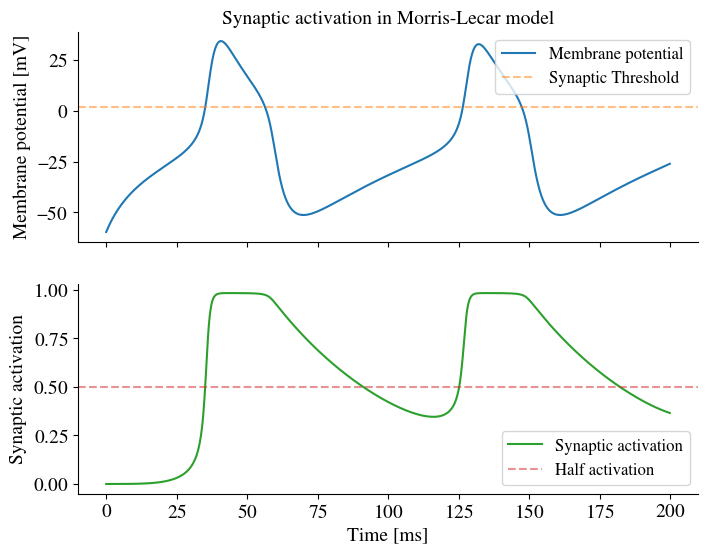

In [51]:
t = np.arange(nt) * dt

fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

ax[0].set_title("Synaptic activation in Morris-Lecar model")
ax[0].plot(t, mem_trace[:, 0], color='C0', label="Membrane potential")
ax[0].axhline(ml._v_t, color='C1', ls='--', alpha=0.5, label="Synaptic Threshold")
ax[0].set_ylabel("Membrane potential [mV]")
ax[0].legend(loc='upper right')
ax[1].plot(t, s_trace[:, 0], color='C2', label="Synaptic activation")
ax[1].axhline(0.5, color='C3', alpha=0.5, ls='--', label="Half activation")
ax[1].set_ylabel("Synaptic activation")
ax[1].set_xlabel("Time [ms]")
ax[1].legend(loc='lower right')

plt.savefig(os.path.join(fig_dir, "synaptic_activation.pdf"), bbox_inches='tight', pad_inches=0.1)
plt.show()